<div style="display:flex;align-items:center;gap:28px;margin:0 0 12px 0;">

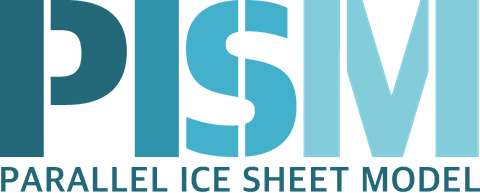
</div>

# PISM-Cloud — Progress

Check in on the runs of a project without the notebook that submitted them. Enter the **Name**,
**Project** and **Bucket** the jobs were submitted with (the same three fields as the ISMIP7 and
glacier apps) and click **Find jobs**: every job id under `s3://{bucket}/{name}/{project}/` is
listed with the run it belongs to (its run script, or the output directory its log names while it
is still running), when its log was last published and how far through its time span the run has
got. Pick one to read its live log below.

Everything is read anonymously from S3, the way the other apps find run scripts and logs, so
neither an Earthdata login nor AWS credentials are needed.

Run this notebook with **Voila** to get a button-driven web page:

```
voila notebooks/pism_cloud_progress_app.ipynb --strip_sources=True
```

In [ ]:
import datetime
import html
import re
import threading
from concurrent.futures import ThreadPoolExecutor

import ipywidgets as widgets
import s3fs
from IPython.display import display

# Single shared session state (single kernel / single user).
state = {
    "jobs": [],  # one dict per job directory found: job_id, label, kind, log
    "trackers": {},  # job_id -> LogTracker, so overview refreshes read only what a log gained
}

PROGRESS_KEY = "{prefix}/logs/progress.log"
TAIL_LINES = 40

# PISM echoes its model date as "S 1986-03-21 21.836h:"; the run script is run
# under ``bash -ex``, so the pism command line -- and with it the leg's
# -time.start / -time.end -- is echoed into the same log. Note the flags are
# emitted sorted, so -time.end comes *before* -time.start; parse them by name.
TIME_OPT_RE = re.compile(r"-time\.(start|end)\s+(\d{4}-\d{2}-\d{2})")
MODEL_DATE_RE = re.compile(r"^S\s+(\d{4}-\d{2}-\d{2})\s+([\d.]+)h", re.MULTILINE)
#: A HyP3 job id: the directory names under the project prefix.
JOB_ID_RE = re.compile(r"^[0-9a-f]{8}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{12}$")
#: The run's output directory, ``.../output/C009/`` (ISMIP7 counter) or
#: ``.../output/RGI2000-v7.0-C-01-12345/`` (glacier), as the run script's
#: ``mkdir -p`` and ``-o`` echo it into the log. An execute job mirrors its
#: ``run_scripts/`` only when it ends, so while it runs the log is all there is.
OUTPUT_DIR_RE = re.compile(r"/output/([^/\s]+)/")
#: How much of a log's head to read for that: the script's echo comes first.
LOG_HEAD_BYTES = 65536
#: Parallel S3 round trips when describing jobs and reading their logs.
S3_WORKERS = 8


def s3():
    """An anonymous S3 client without instance caching, so every call sees the current listing."""
    return s3fs.S3FileSystem(anon=True, skip_instance_cache=True)


def leg_progress(bounds, stamp):
    """How far through its time span the running leg is.

    ``bounds`` holds the leg's ``-time.start`` / ``-time.end`` and ``stamp`` the
    latest model date PISM printed, as ``(date, hours)``. Returns
    (fraction, current, start, end) or None when either is still missing --
    PISM prints no model date until it has taken its first step.
    """
    if stamp is None or "start" not in bounds or "end" not in bounds:
        return None
    try:
        start = datetime.datetime.fromisoformat(bounds["start"])
        end = datetime.datetime.fromisoformat(bounds["end"])
        current = datetime.datetime.fromisoformat(stamp[0]) + datetime.timedelta(hours=float(stamp[1]))
    except ValueError:
        return None
    span = (end - start).total_seconds()
    if span <= 0:
        return None
    return max(0.0, min(1.0, (current - start).total_seconds() / span)), current, start, end


def run_progress(text):
    """``leg_progress`` of a whole log: the last leg's bounds and its latest model date."""
    bounds = {}
    for kind, value in TIME_OPT_RE.findall(text):
        # Last wins, so a multi-leg run tracks the leg running now.
        bounds[kind] = value
    stamps = MODEL_DATE_RE.findall(text)
    return leg_progress(bounds, stamps[-1] if stamps else None)


class LogTracker:
    """Follow one log incrementally.

    Logs grow to tens of MB; the first update reads the whole file, every
    later one only the bytes appended since, and the leg bounds and latest
    model date are carried along, so refreshing the overview stays cheap.
    """

    def __init__(self):
        self.offset = 0
        self.bounds = {}
        self.stamp = None
        self.partial = ""  # the unfinished last line, parsed with the next read

    def update(self, fs, key, size):
        """Read what ``key`` gained since the last update; ``size`` is its current length."""
        if size < self.offset:  # rewritten from scratch: start over
            self.__init__()
        if size == self.offset:
            return
        text = self.partial + fs.cat_file(key, start=self.offset, end=size).decode("utf-8", errors="replace")
        self.offset = size
        cut = text.rfind("\n")
        self.partial, text = text[cut + 1:], text[: cut + 1]
        for kind, value in TIME_OPT_RE.findall(text):
            self.bounds[kind] = value
        stamps = MODEL_DATE_RE.findall(text)
        if stamps:
            self.stamp = stamps[-1]

    def progress(self):
        return leg_progress(self.bounds, self.stamp)

## 1. Project

The three fields every PISM-Cloud job is submitted with. Jobs live at
`s3://{bucket}/{name}/{project}/{job_id}/`: a *prepare* job leaves `run_scripts/`, an *execute*
job publishes `logs/progress.log` every 30 s while it runs and mirrors its output at the end.

In [ ]:
name_w = widgets.Text(value="ismip7_production", description="Name:")
project_w = widgets.Text(value="2026_10_core", description="Project:")
bucket_w = widgets.Text(value="pism-cloud-data", description="Bucket:")
find_btn = widgets.Button(description="Find jobs", button_style="primary", icon="search")
find_out = widgets.Output()


def _project_prefix():
    return f"{bucket_w.value}/{name_w.value}/{project_w.value}"


def _progress_key(job_id):
    """Key the executor publishes to for this job."""
    prefix = f"{name_w.value}/{project_w.value}/{job_id}"
    return PROGRESS_KEY.format(prefix=prefix)


def _script_label(scripts):
    """``submit_g900m_id_C001.sh`` -> ``g900m_id_C001``; several scripts are joined."""
    names = []
    for script in scripts:
        name = script.rsplit("/", 1)[-1]
        name = name.removeprefix("submit_").removesuffix(".sh")
        names.append(name)
    return ", ".join(names)


def _describe_job(fs, job_id):
    """What the job's directory holds: its run script(s) and, for an execute job, its log."""
    base = f"{_project_prefix()}/{job_id}"
    try:
        scripts = fs.ls(f"{base}/run_scripts/")
    except FileNotFoundError:
        scripts = []
    key = f"{bucket_w.value}/{_progress_key(job_id)}"
    try:
        info = fs.info(key)
        log = {"key": key, "size": info.get("size", 0), "modified": info.get("LastModified")}
    except FileNotFoundError:
        log = None
    kind = "execute" if log is not None else ("prepare" if scripts else "other")
    label = _script_label(scripts)
    if not label and log is not None:
        label = _log_label(fs, key)
    return {"job_id": job_id, "label": label or "—", "kind": kind, "log": log}


def _log_label(fs, key):
    """The run's output directory named in the head of its log, or an empty string."""
    try:
        head = fs.cat_file(key, start=0, end=LOG_HEAD_BYTES).decode("utf-8", errors="replace")
    except Exception:  # noqa: BLE001
        return ""
    match = OUTPUT_DIR_RE.search(head)
    return match.group(1) if match else ""


def find_jobs():
    """Every job directory under the project prefix, described; execute jobs first, then by script."""
    fs = s3()
    entries = fs.ls(_project_prefix() + "/", detail=True)
    job_ids = sorted(
        e["name"].rstrip("/").rsplit("/", 1)[-1] for e in entries
        if e["type"] == "directory" and JOB_ID_RE.match(e["name"].rstrip("/").rsplit("/", 1)[-1])
    )
    with ThreadPoolExecutor(max_workers=S3_WORKERS) as pool:
        jobs = list(pool.map(lambda job_id: _describe_job(fs, job_id), job_ids))
    order = {"execute": 0, "prepare": 1, "other": 2}
    jobs.sort(key=lambda j: (order[j["kind"]], j["label"], j["job_id"]))
    return jobs


def _find_jobs(_):
    find_out.clear_output()
    with find_out:
        try:
            state["jobs"] = find_jobs()
        except Exception as exc:  # noqa: BLE001
            print(f"❌ could not list s3://{_project_prefix()}/: {exc}")
            return
        counts = {}
        for job in state["jobs"]:
            counts[job["kind"]] = counts.get(job["kind"], 0) + 1
        summary = ", ".join(f"{n} {kind}" for kind, n in sorted(counts.items())) or "none"
        print(f"✅ {len(state['jobs'])} job(s) under s3://{_project_prefix()}/  ({summary})")
    # The overview and the log picker below follow the new list.
    for hook in state.get("on_jobs", []):
        hook()


state["on_jobs"] = []
find_btn.on_click(_find_jobs)
display(widgets.VBox([name_w, project_w, bucket_w, find_btn, find_out]))

## 2. Overview

One row per job. **Progress** is how far through its time span the current PISM leg is, read
off the model dates PISM prints against the `-time.start` / `-time.end` the run script echoes,
as in the live log below. **Log updated** is when the executor last published the log; a run
that stopped publishing minutes ago and is short of 100 % has most likely failed — open its log.
Prepare jobs publish no log and show only their scripts. The first refresh reads every log once;
later ones fetch only what each log has gained since, so auto-refresh is cheap.

In [ ]:
OVERVIEW_REFRESH_S = 60.0

overview_btn = widgets.Button(description="Refresh overview", icon="refresh")
overview_auto_w = widgets.Checkbox(value=False, description=f"Auto-refresh ({OVERVIEW_REFRESH_S:.0f}s)")
overview_out = widgets.HTML()
_overview_timer = {"t": None}


def _age(modified):
    """``3 min ago`` for a timestamp, or an empty string."""
    if modified is None:
        return ""
    now = datetime.datetime.now(datetime.timezone.utc)
    seconds = max(0.0, (now - modified).total_seconds())
    if seconds < 90:
        return f"{seconds:.0f} s ago"
    if seconds < 5400:
        return f"{seconds / 60:.0f} min ago"
    if seconds < 172800:
        return f"{seconds / 3600:.1f} h ago"
    return f"{seconds / 86400:.1f} d ago"


def _progress_cell(fraction, current, start, end):
    """An inline bar with the model date under it."""
    percent = 100 * fraction
    colour = "#5cb85c" if fraction >= 1.0 else "#337ab7"
    return (
        f"<div style='background:#eee;width:160px;height:10px;border-radius:3px'>"
        f"<div style='background:{colour};width:{percent:.1f}%;height:10px;border-radius:3px'></div></div>"
        f"<small><b>{percent:.1f}%</b> &nbsp;<code>{current:%Y-%m-%d}</code>"
        f"<span style='color:#888'> of {start:%Y-%m-%d} – {end:%Y-%m-%d}</span></small>"
    )


def _row(fs, job):
    """One table row: the log's current size and date, and whatever it gained since the last refresh."""
    log = job["log"]
    progress = "<i>no log</i>"
    updated = ""
    if log is None:
        # A prepare job at the last look; an execute job may have started publishing since.
        try:
            info = fs.info(f"{bucket_w.value}/{_progress_key(job['job_id'])}")
        except FileNotFoundError:
            info = None
        if info is not None:
            log = job["log"] = {"key": f"{bucket_w.value}/{_progress_key(job['job_id'])}", "size": 0, "modified": None}
            job["kind"] = "execute"
    if log is not None:
        try:
            info = fs.info(log["key"])
            log["size"], log["modified"] = info.get("size", 0), info.get("LastModified")
            tracker = state["trackers"].setdefault(job["job_id"], LogTracker())
            tracker.update(fs, log["key"], log["size"])
        except Exception as exc:  # noqa: BLE001
            progress = f"<i>could not read the log: {html.escape(str(exc))}</i>"
        else:
            result = tracker.progress()
            progress = _progress_cell(*result) if result else "<i>waiting for PISM's first model date…</i>"
        if log["modified"] is not None:
            updated = f"{log['modified']:%Y-%m-%d %H:%M} UTC<br><small>{_age(log['modified'])}</small>"
    return (
        f"<tr><td><code>{job['job_id']}</code></td><td>{job['kind']}</td>"
        f"<td><code>{html.escape(job['label'])}</code></td><td>{updated}</td><td>{progress}</td></tr>"
    )


def _render_overview():
    jobs = state["jobs"]
    if not jobs:
        overview_out.value = "<i>No jobs found yet — set the project above and click Find jobs.</i>"
        return
    fs = s3()
    stamp = datetime.datetime.now().strftime("%H:%M:%S")
    with ThreadPoolExecutor(max_workers=S3_WORKERS) as pool:
        rows = "".join(pool.map(lambda job: _row(fs, job), jobs))
    overview_out.value = (
        f"<small>{len(jobs)} job(s), refreshed {stamp}</small>"
        "<table style='border-collapse:collapse;font-size:12px'>"
        "<tr style='text-align:left;border-bottom:1px solid #999'>"
        "<th style='padding:4px 10px'>Job</th><th style='padding:4px 10px'>Kind</th>"
        "<th style='padding:4px 10px'>Script</th><th style='padding:4px 10px'>Log updated</th>"
        "<th style='padding:4px 10px'>Progress</th></tr>"
        + rows.replace("<td>", "<td style='padding:4px 10px;vertical-align:top;border-bottom:1px solid #ddd'>")
        + "</table>"
    )


def _schedule_overview():
    if not overview_auto_w.value:
        return
    _render_overview()
    timer = threading.Timer(OVERVIEW_REFRESH_S, _schedule_overview)
    timer.daemon = True
    _overview_timer["t"] = timer
    timer.start()


def _toggle_overview_auto(change):
    if change["new"]:
        _schedule_overview()
    elif _overview_timer["t"] is not None:
        _overview_timer["t"].cancel()


overview_btn.on_click(lambda _: _render_overview())
overview_auto_w.observe(_toggle_overview_auto, names="value")
state["on_jobs"].append(_render_overview)
display(widgets.VBox([widgets.HBox([overview_btn, overview_auto_w]), overview_out]))

## 3. Live run log

Shows what the simulation is doing *while* it runs. `pism-glacier-execute` and
`pism-ismip7-greenland-execute` publish the run script's output to `…/{job_id}/logs/progress.log`
every 30 s, and this reads it back anonymously.

The bar underneath tracks how far through its time span the current PISM leg is, read off
the model dates PISM prints (`S 1986-03-21 21.836h:`) against the `-time.start` / `-time.end`
the run script echoes. A run with an init leg shows the leg that is running now.

Pick a job (the execute jobs found in step 1) and tick **Follow**.

In [ ]:
job_w = widgets.Dropdown(description="Job:", layout=widgets.Layout(width="620px"))
follow_w = widgets.Checkbox(value=False, description="Follow (15s)")
log_out = widgets.Output(layout=widgets.Layout(
    border="1px solid #ddd", height="420px", overflow="auto", width="100%"))
progress_w = widgets.FloatProgress(value=0, min=0, max=100, bar_style="info",
                                   layout=widgets.Layout(width="55%"))
progress_label_w = widgets.HTML(value="<i>not started</i>")
_log_timer = {"t": None}


def _job_options():
    """The jobs found in step 1, execute jobs first, labelled by their run script."""
    return [(f"{j['label']}  —  {j['job_id']}  ({j['kind']})", j["job_id"]) for j in state["jobs"]]


def _set_progress(text):
    """Point the bar at wherever the run has got to."""
    result = run_progress(text) if text else None
    if result is None:
        progress_w.value = 0
        progress_w.bar_style = "info"
        progress_label_w.value = "<i>waiting for PISM's first model date…</i>"
        return
    fraction, current, start, end = result
    progress_w.value = 100 * fraction
    progress_w.bar_style = "success" if fraction >= 1.0 else "info"
    progress_label_w.value = (
        f"<b>{fraction:.1%}</b> &nbsp;&nbsp; <code>{current:%Y-%m-%d}</code>"
        f"<span style='color:#888'> &nbsp; of {start:%Y-%m-%d} – {end:%Y-%m-%d}</span>"
    )


def _render_log():
    job_id = job_w.value
    text = ""
    message = None
    if not job_id:
        message = "No job selected — click Find jobs in step 1 first."
    else:
        key = _progress_key(job_id)
        try:
            text = s3().cat_file(f"{bucket_w.value}/{key}").decode("utf-8", errors="replace")
        except FileNotFoundError:
            message = (f"No log at s3://{bucket_w.value}/{key}\n"
                       "(a prepare job publishes none; an execute job's first publish is ~30 s in)")
        except Exception as exc:  # noqa: BLE001
            message = f"❌ could not read the log: {exc}"
    # The bar reads the whole log, not just the tail shown below it.
    _set_progress(text)
    log_out.clear_output(wait=True)
    with log_out:
        if message is not None:
            print(message)
            return
        lines = text.splitlines()
        shown = lines[-TAIL_LINES:]
        stamp = datetime.datetime.now().strftime("%H:%M:%S")
        print(f"{len(lines)} lines, last {len(shown)} shown (refreshed {stamp})")
        print("-" * 100)
        print("\n".join(shown))


def _reload_jobs():
    job_w.options = _job_options()
    if job_w.options:
        job_w.value = job_w.options[0][1]


def _schedule_log():
    if not follow_w.value:
        return
    _render_log()
    timer = threading.Timer(15.0, _schedule_log)
    timer.daemon = True
    _log_timer["t"] = timer
    timer.start()


def _toggle_follow(change):
    if change["new"]:
        _schedule_log()
    elif _log_timer["t"] is not None:
        # Cancel, or every toggle leaks another timer.
        _log_timer["t"].cancel()


show_log_btn = widgets.Button(description="Show log", icon="file-text")
show_log_btn.on_click(lambda _: _render_log())
follow_w.observe(_toggle_follow, names="value")
state["on_jobs"].append(_reload_jobs)
display(widgets.VBox([
    job_w,
    widgets.HBox([show_log_btn, follow_w]),
    log_out,
    widgets.HBox([progress_w, progress_label_w]),
]))

# Open with the default project already listed, so the page is useful before the first click.
_find_jobs(None)